## Method Delta vs NL2P-1

This section uses the current top-level result directories rather than the older
`results/experiment/` runs. Each delta is computed within the same
`model + dataset` pair:

`delta = strategy F1 - nl2p_1 F1`

Positive bars mean the strategy improved over the original NL2P-1 prompt.

In [1]:
import sys
from pathlib import Path

search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (path for path in search_roots if (path / "src/eval/read_eval.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Project root not found. Start Jupyter inside the llm-action-extraction repository.")
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    read_eval_results,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)


In [2]:
BASE_METHOD = "nl2p_1"
COMPARE_METHODS = [method for method in METHOD_ORDER if method != BASE_METHOD]

baseline_df = result_df[result_df["method"].astype(str) == BASE_METHOD][
    ["domain", "model", "Action F1", "Argument F1"]
].rename(
    columns={
        "Action F1": "Action F1 baseline",
        "Argument F1": "Argument F1 baseline",
    }
)

method_delta_df = result_df[result_df["method"].astype(str).isin(COMPARE_METHODS)].merge(
    baseline_df,
    on=["domain", "model"],
    how="inner",
)
method_delta_df["Action F1 delta"] = method_delta_df["Action F1"] - method_delta_df["Action F1 baseline"]
method_delta_df["Argument F1 delta"] = method_delta_df["Argument F1"] - method_delta_df["Argument F1 baseline"]

display(method_delta_df.head(5))


,domain,method,model,Action Precision,Action Recall,Action F1,Argument Precision,Argument Recall,Argument F1,perfect_action_argument_matches,argument_mismatch_actions,matched_action_events,Action F1 baseline,Argument F1 baseline,Action F1 delta,Argument F1 delta
0,win2k,nl2p_1_ablation,gemma3-12b,0.951572,0.838323,0.891365,0.813264,0.554102,0.659123,506,614,1120,0.888710,0.654106,0.002655,0.005017
1,win2k,nl2p_1_coref,gemma3-12b,0.964317,0.828721,0.891392,0.793345,0.546112,0.646912,487,621,1108,0.888710,0.654106,0.002681,-0.007194
2,win2k,nl2p_1_ablation,gemma3-27b,0.938552,0.839608,0.886328,0.826163,0.549971,0.660351,506,609,1115,0.879192,0.667396,0.007136,-0.007045
3,win2k,nl2p_1_coref,gemma3-27b,0.953222,0.816327,0.879479,0.834566,0.547937,0.661538,483,597,1080,0.879192,0.667396,0.000287,-0.005858
4,win2k,nl2p_1_ablation,llama3-70b,0.942128,0.834842,0.885246,0.822404,0.533373,0.647080,471,636,1107,0.889068,0.646953,-0.003822,0.000127


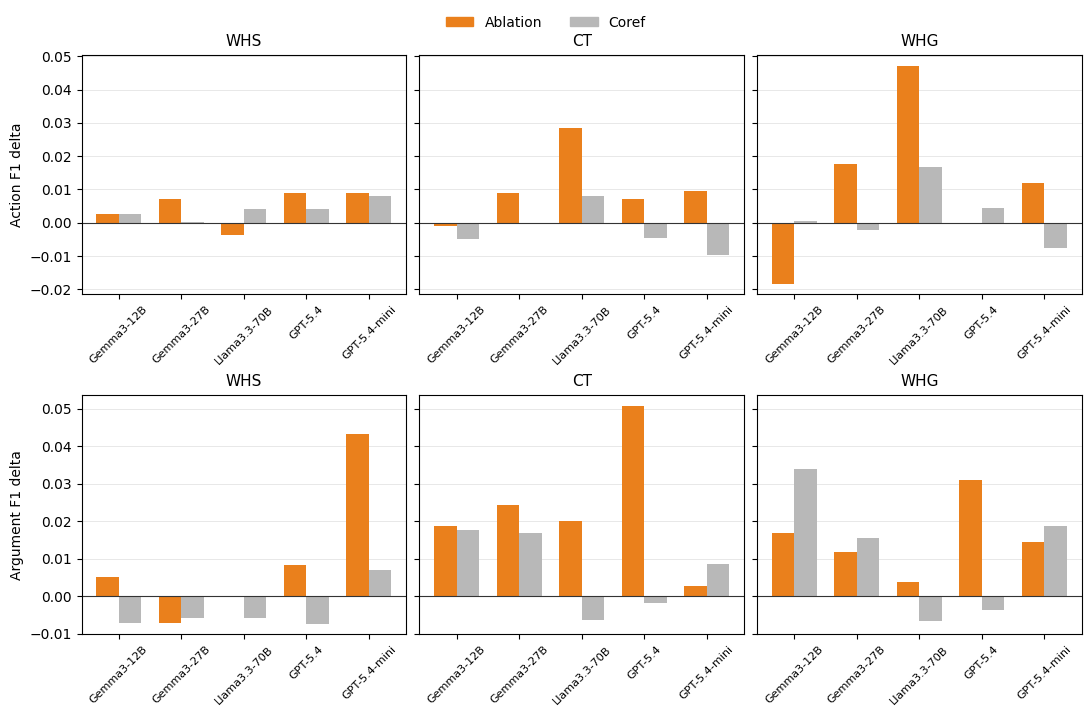

In [3]:
method_colors = {
    "nl2p_1_ablation": "#ea801c",
    "nl2p_1_coref": "#b8b8b8",
}
offsets = np.linspace(-0.18, 0.18, len(COMPARE_METHODS))
metrics = ["Action F1 delta", "Argument F1 delta"]
y_labels = ["Action F1 delta", "Argument F1 delta"]
models = [model for model in MODEL_ORDER if model in set(method_delta_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(DOMAIN_ORDER),
    figsize=(10.8, 6.8),
    sharey="row",
    constrained_layout=True,
)

x = np.arange(len(models))
width = 0.36

for row_idx, metric in enumerate(metrics):
    for col_idx, domain in enumerate(DOMAIN_ORDER):
        ax = axes[row_idx, col_idx]
        panel = method_delta_df[method_delta_df["domain"].astype(str) == domain]

        for method_key, offset in zip(COMPARE_METHODS, offsets):
            values = []
            for model in models:
                row = panel[
                    (panel["method"].astype(str) == method_key)
                    & (panel["model"].astype(str) == model)
                ]
                values.append(np.nan if row.empty else float(row.iloc[0][metric]))

            ax.bar(
                x + offset,
                values,
                width=width,
                color=method_colors[method_key],
                label=METHOD_LABELS[method_key],
                edgecolor="none",
            )

        ax.axhline(0.0, color="#333333", linewidth=0.8)
        ax.set_title(DOMAIN_LABELS[domain], fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
        ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
        if col_idx == 0:
            ax.set_ylabel(y_labels[row_idx])

handles = [
    plt.Rectangle((0, 0), 1, 1, color=method_colors[method_key], label=METHOD_LABELS[method_key])
    for method_key in COMPARE_METHODS
]
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=len(COMPARE_METHODS),
    frameon=False,
)
plt.show()
